In [ ]:

# : Install and Import Libraries

!pip install torch torchvision torchaudio transformers pandas numpy scikit-learn matplotlib seaborn emoji

import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import emoji
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification

# Use GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 23.3 MB/s eta 0:00:00
Using device: cuda


In [ ]:
#
# Load Dataset
#
dataset_path = 'text.csv'
df = pd.read_csv(dataset_path)

print("\n--- Class Distribution ---")
print(df['Feeling'].value_counts())



--- Class Distribution ---
Feeling
happy       3928
sad         2849
angry       1341
fear         863
disgust      637
surprise     399
Name: count, dtype: int64


In [ ]:
df.rename(columns={
    'input': 'text',
    'Feeling': 'label'
}, inplace=True)

In [ ]:
# Text Preprocessing
def preprocess_text(text):
    text = str(text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # URL
    text = re.sub(r'@\w+', '', text) # Mentions
    text = re.sub(r'#\w+', '', text) # Hashtags
    text = emoji.demojize(text)      # Emoji preserve meaning
    text = text.lower()
    return text.strip()

df['cleaned_text'] = df['text'].apply(preprocess_text)
df.dropna(subset=['cleaned_text', 'label'], inplace=True)

# Label Encoding
label_encoder = LabelEncoder()
df['label_id'] = label_encoder.fit_transform(df['label'])

print("\nLabel Mapping:")
for i, label in enumerate(label_encoder.classes_):
    print(f"{i}: {label}")



Label Mapping:
0: angry
1: disgust
2: fear
3: happy
4: sad
5: surprise


In [ ]:
# =========================
# Train-Test Split & Class Weights
# =========================
X = df['cleaned_text'].values
y = df['label_id'].values

# 80/20 train/test split
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Use 10% of training data for Validation
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.1, random_state=42, stratify=y_train_full)

# Compute Class Weights for Imbalanced Data
unique_classes = np.unique(y_train)
weights_arr = compute_class_weight('balanced', classes=unique_classes, y=y_train)
class_weights_tensor = torch.tensor(weights_arr, dtype=torch.float32).to(device)

print(f"Training set: {X_train.shape[0]} \nValidation set: {X_val.shape[0]} \nTest set: {X_test.shape[0]}")


Training set: 7211 
Validation set: 802 
Test set: 2004


In [ ]:
# =========================
#  Tokenizers setup (DistilBERT + Pure PyTorch BiLSTM Text Vectorization)
# =========================

# 1. DistilBERT Tokenizer
MODEL_NAME = 'distilbert-base-uncased'
bert_tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)
MAX_LENGTH_BERT = 128

# 2. Keras Tokenizer Alternative (No TF Dependency)
class SimpleTokenizer:
    def __init__(self, max_words=15000):
        self.max_words = max_words
        self.word2idx = {"<PAD>": 0, "<UNK>": 1}

    def fit(self, texts):
        words = []
        for t in texts:
            words.extend(str(t).split())
        counts = Counter(words)
        vocab = [w for w, c in counts.most_common(self.max_words - 2)]
        for i, w in enumerate(vocab):
            self.word2idx[w] = i + 2

    def transform(self, texts):
        return [[self.word2idx.get(w, 1) for w in str(t).split()] for t in texts]

def pad_sequences_pure(sequences, maxlen=128):
    padded = np.zeros((len(sequences), maxlen), dtype=int)
    for i, seq in enumerate(sequences):
        if len(seq) > maxlen:
            seq = seq[:maxlen]
        padded[i, :len(seq)] = seq
    return padded

lstm_tokenizer = SimpleTokenizer(max_words=15000)
lstm_tokenizer.fit(X_train)
MAX_LENGTH_LSTM = 128
VOCAB_SIZE = len(lstm_tokenizer.word2idx)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
# =========================
# PyTorch Dataset Config
# =========================
class EmotionDatasetBERT(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.encodings = tokenizer(list(texts), truncation=True, padding='max_length', max_length=max_length, return_tensors='pt')
        self.labels = labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return { 'input_ids': self.encodings['input_ids'][idx], 'attention_mask': self.encodings['attention_mask'][idx], 'labels': torch.tensor(self.labels[idx], dtype=torch.long) }

class EmotionDatasetLSTM(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        seqs = tokenizer.transform(texts)
        self.padded = pad_sequences_pure(seqs, maxlen=max_length)
        self.labels = labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return { 'input_ids': torch.tensor(self.padded[idx], dtype=torch.long), 'labels': torch.tensor(self.labels[idx], dtype=torch.long) }

BATCH_SIZE = 16

# DistilBERT Dataloaders
train_loader_bert = DataLoader(EmotionDatasetBERT(X_train, y_train, bert_tokenizer, MAX_LENGTH_BERT), batch_size=BATCH_SIZE, shuffle=True)
val_loader_bert = DataLoader(EmotionDatasetBERT(X_val, y_val, bert_tokenizer, MAX_LENGTH_BERT), batch_size=BATCH_SIZE, shuffle=False)
test_loader_bert = DataLoader(EmotionDatasetBERT(X_test, y_test, bert_tokenizer, MAX_LENGTH_BERT), batch_size=BATCH_SIZE, shuffle=False)

# BiLSTM Dataloaders
train_loader_lstm = DataLoader(EmotionDatasetLSTM(X_train, y_train, lstm_tokenizer, MAX_LENGTH_LSTM), batch_size=BATCH_SIZE, shuffle=True)
val_loader_lstm = DataLoader(EmotionDatasetLSTM(X_val, y_val, lstm_tokenizer, MAX_LENGTH_LSTM), batch_size=BATCH_SIZE, shuffle=False)
test_loader_lstm = DataLoader(EmotionDatasetLSTM(X_test, y_test, lstm_tokenizer, MAX_LENGTH_LSTM), batch_size=BATCH_SIZE, shuffle=False)


In [ ]:
# =========================
#  Model Architectures
# =========================
num_classes = len(label_encoder.classes_)

# 1. DistilBERT setup
bert_model = DistilBertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=num_classes).to(device)

# 2. BiLSTM setup
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=100, hidden_dim=64, num_classes=6):
        super(BiLSTMClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, input_ids):
        embedded = self.embedding(input_ids)
        _, (hn, _) = self.lstm(embedded)
        hidden = torch.cat((hn[-2,:,:], hn[-1,:,:]), dim=1)
        out = self.dropout(hidden)
        return self.fc(out)

lstm_model = BiLSTMClassifier(vocab_size=VOCAB_SIZE, num_classes=num_classes).to(device)


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
# =========================
# Callbacks (EarlyStopping)
# =========================
class EarlyStopping:
    def __init__(self, patience=3, path='best_model.pth'):
        self.patience = patience
        self.path = path
        self.best_loss = np.inf
        self.counter = 0
        self.early_stop = False

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss:
            print(f'Validation loss decreased ({self.best_loss:.4f} --> {val_loss:.4f}). Saving model!')
            self.best_loss = val_loss
            torch.save(model.state_dict(), self.path)
            self.counter = 0
        else:
            self.counter += 1
            print(f'EarlyStopping counter: {self.counter} of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True


In [ ]:
# =========================
# C Generic PyTorch Training Engine
# =========================
def train_model(model, train_loader, val_loader, optimizer, scheduler, early_stopping, epochs=10, is_bert=True):
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        total_train_loss, train_correct, train_samples = 0, 0, 0

        for batch in train_loader:
            optimizer.zero_grad()
            labels = batch['labels'].to(device)

            if is_bert:
                outputs = model(input_ids=batch['input_ids'].to(device), attention_mask=batch['attention_mask'].to(device))
                logits = outputs.logits
            else:
                logits = model(batch['input_ids'].to(device))

            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            train_correct += (preds == labels).sum().item()
            train_samples += labels.size(0)

        avg_train_loss = total_train_loss / len(train_loader)
        train_acc = train_correct / train_samples

        # Validation
        model.eval()
        total_val_loss, val_correct, val_samples = 0, 0, 0
        with torch.no_grad():
            for batch in val_loader:
                labels = batch['labels'].to(device)
                if is_bert:
                    outputs = model(input_ids=batch['input_ids'].to(device), attention_mask=batch['attention_mask'].to(device))
                    logits = outputs.logits
                else:
                    logits = model(batch['input_ids'].to(device))

                loss = criterion(logits, labels)
                total_val_loss += loss.item()
                preds = torch.argmax(logits, dim=1)
                val_correct += (preds == labels).sum().item()
                val_samples += labels.size(0)

        avg_val_loss = total_val_loss / len(val_loader)
        val_acc = val_correct / val_samples

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch+1:02d} | Train Loss: {avg_train_loss:.4f}, Acc: {train_acc:.4f} | Val Loss: {avg_val_loss:.4f}, Acc: {val_acc:.4f}")

        scheduler.step(avg_val_loss)
        early_stopping(avg_val_loss, model)
        if early_stopping.early_stop:
            print("Early stopping triggered!")
            break

    return history


In [ ]:
# =========================
#  Train DistilBERT Model
# =========================
EPOCHS = 10
optimizer_bert = torch.optim.AdamW(bert_model.parameters(), lr=2e-5)

#  ReduceLROnPlateau (no verbose argument)
scheduler_bert = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_bert,
    mode='min',
    factor=0.5,
    patience=2
)

early_stopping_bert = EarlyStopping(patience=3, path='best_distilbert.pth')

print("\n=== Training DistilBERT ===")
history_bert = train_model(
    bert_model,
    train_loader_bert,
    val_loader_bert,
    optimizer_bert,
    scheduler_bert,
    early_stopping_bert,
    epochs=EPOCHS,
    is_bert=True
)

# Reload best weights
bert_model.load_state_dict(torch.load('best_distilbert.pth'))
print("DistilBERT successfully loaded best weights.")


=== Training DistilBERT ===
Epoch 01 | Train Loss: 0.9957, Acc: 0.6858 | Val Loss: 0.4388, Acc: 0.8529
Validation loss decreased (inf --> 0.4388). Saving model!
Epoch 02 | Train Loss: 0.3267, Acc: 0.8902 | Val Loss: 0.3351, Acc: 0.8766
Validation loss decreased (0.4388 --> 0.3351). Saving model!
Epoch 03 | Train Loss: 0.2025, Acc: 0.9250 | Val Loss: 0.3483, Acc: 0.9102
EarlyStopping counter: 1 of 3
Epoch 04 | Train Loss: 0.1315, Acc: 0.9505 | Val Loss: 0.3387, Acc: 0.8990
EarlyStopping counter: 2 of 3
Epoch 05 | Train Loss: 0.0934, Acc: 0.9638 | Val Loss: 0.4498, Acc: 0.9127
EarlyStopping counter: 3 of 3
Early stopping triggered!
DistilBERT successfully loaded best weights.


In [ ]:
# =========================
# Train BiLSTM Model
# =========================
optimizer_lstm = torch.optim.AdamW(lstm_model.parameters(), lr=1e-3)

# ReduceLROnPlateau (no verbose)
scheduler_lstm = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_lstm,
    mode='min',
    factor=0.5,
    patience=2
)

early_stopping_lstm = EarlyStopping(patience=3, path='best_bilstm.pth')

print("\n=== Training BiLSTM ===")
history_lstm = train_model(
    lstm_model,
    train_loader_lstm,
    val_loader_lstm,
    optimizer_lstm,
    scheduler_lstm,
    early_stopping_lstm,
    epochs=EPOCHS,
    is_bert=False
)

# Reload best weights
lstm_model.load_state_dict(torch.load('best_bilstm.pth'))
print("BiLSTM successfully loaded best weights.")


=== Training BiLSTM ===
Epoch 01 | Train Loss: 1.6264, Acc: 0.3515 | Val Loss: 1.5121, Acc: 0.3915
Validation loss decreased (inf --> 1.5121). Saving model!
Epoch 02 | Train Loss: 1.2919, Acc: 0.4675 | Val Loss: 1.2559, Acc: 0.5461
Validation loss decreased (1.5121 --> 1.2559). Saving model!
Epoch 03 | Train Loss: 0.9712, Acc: 0.5887 | Val Loss: 1.1698, Acc: 0.5611
Validation loss decreased (1.2559 --> 1.1698). Saving model!
Epoch 04 | Train Loss: 0.7035, Acc: 0.7057 | Val Loss: 1.1049, Acc: 0.6272
Validation loss decreased (1.1698 --> 1.1049). Saving model!
Epoch 05 | Train Loss: 0.5108, Acc: 0.7814 | Val Loss: 1.1694, Acc: 0.6384
EarlyStopping counter: 1 of 3
Epoch 06 | Train Loss: 0.3676, Acc: 0.8470 | Val Loss: 1.2649, Acc: 0.6783
EarlyStopping counter: 2 of 3
Epoch 07 | Train Loss: 0.2861, Acc: 0.8832 | Val Loss: 1.1826, Acc: 0.6895
EarlyStopping counter: 3 of 3
Early stopping triggered!
BiLSTM successfully loaded best weights.


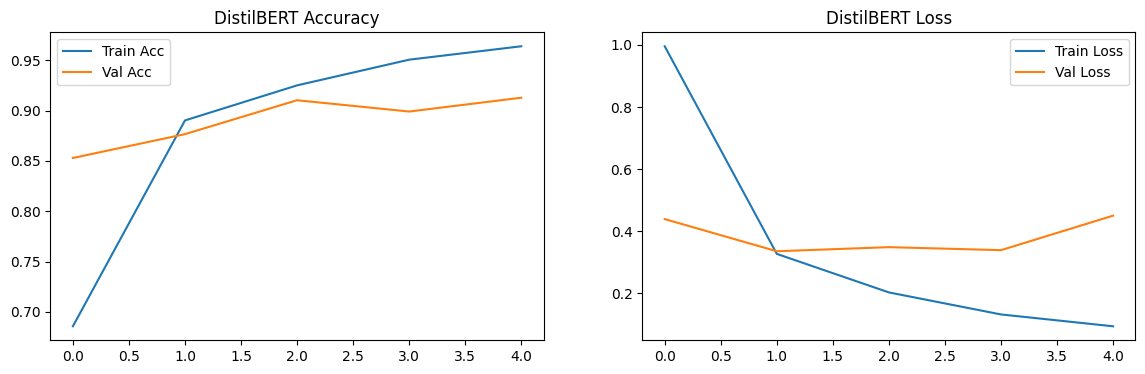

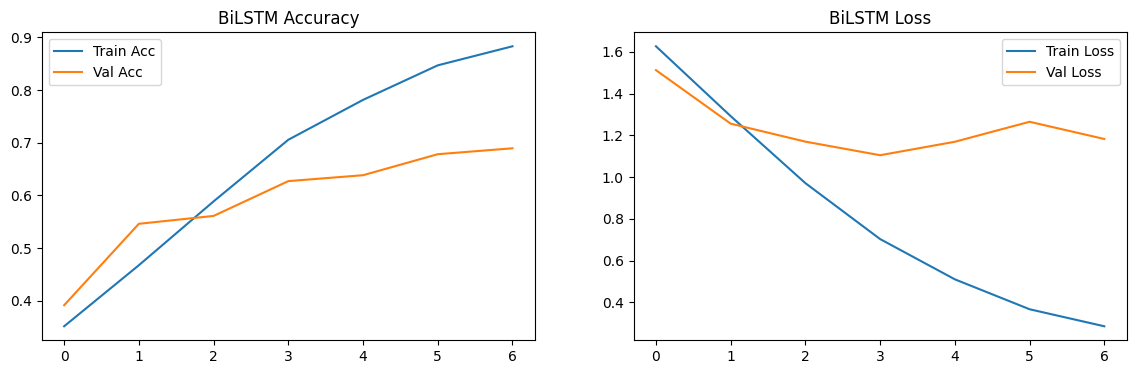

In [ ]:
# =========================
# Plot Training Curves (Loss and Accuracy)
# =========================
def plot_curves(history, title_prefix):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    ax1.plot(history['train_acc'], label='Train Acc')
    ax1.plot(history['val_acc'], label='Val Acc')
    ax1.set_title(f'{title_prefix} Accuracy')
    ax1.legend()

    ax2.plot(history['train_loss'], label='Train Loss')
    ax2.plot(history['val_loss'], label='Val Loss')
    ax2.set_title(f'{title_prefix} Loss')
    ax2.legend()
    plt.show()

plot_curves(history_bert, "DistilBERT")
plot_curves(history_lstm, "BiLSTM")


DistilBERT Confusion Matrix:
[[ 97   0   0   6   1   3]
 [  1  49   1   0   0   0]
 [  1   0  65   1   1   1]
 [ 10   3  12 270   9  11]
 [ 10   1   7   5 196   9]
 [  1   0   2   3   0  26]]


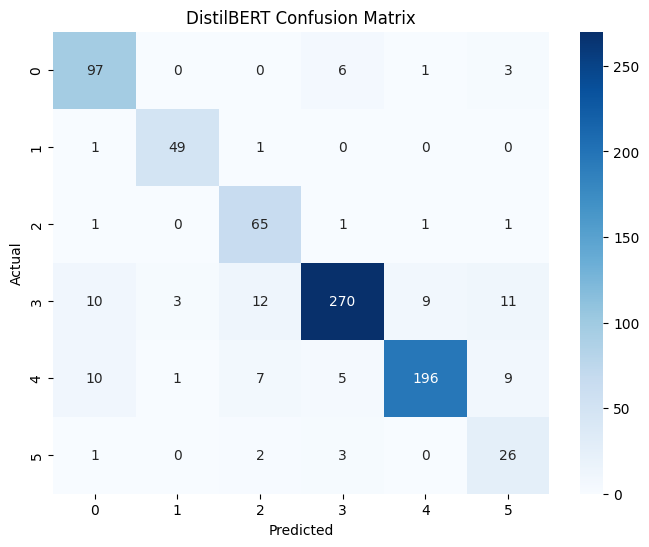

              precision    recall  f1-score   support

           0       0.81      0.91      0.85       107
           1       0.92      0.96      0.94        51
           2       0.75      0.94      0.83        69
           3       0.95      0.86      0.90       315
           4       0.95      0.86      0.90       228
           5       0.52      0.81      0.63        32

    accuracy                           0.88       802
   macro avg       0.82      0.89      0.84       802
weighted avg       0.89      0.88      0.88       802



In [ ]:
# Put model in evaluation mode
bert_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in val_loader_bert:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = bert_model(input_ids, attention_mask)  # returns SequenceClassifierOutput
        logits = outputs.logits  # ✅ extract logits
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Confusion matrix
cm_bert = confusion_matrix(all_labels, all_preds)
print("DistilBERT Confusion Matrix:")
print(cm_bert)

# Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(cm_bert, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("DistilBERT Confusion Matrix")
plt.show()

# Classification report
print(classification_report(all_labels, all_preds))

BiLSTM Confusion Matrix:
[[ 61   2  11  13  12   8]
 [  5  32   7   6   0   1]
 [  2   3  44  14   1   5]
 [ 18  19  35 217   7  19]
 [ 27   8  21  30 126  16]
 [  1   1   4   3   0  23]]


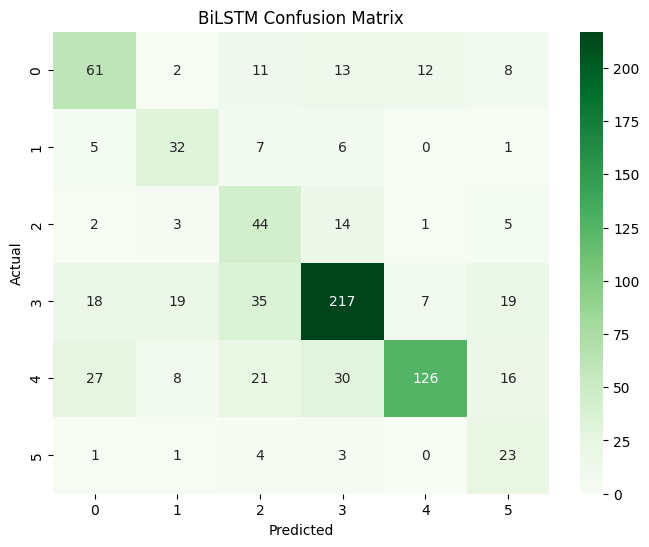

              precision    recall  f1-score   support

           0       0.54      0.57      0.55       107
           1       0.49      0.63      0.55        51
           2       0.36      0.64      0.46        69
           3       0.77      0.69      0.73       315
           4       0.86      0.55      0.67       228
           5       0.32      0.72      0.44        32

    accuracy                           0.63       802
   macro avg       0.56      0.63      0.57       802
weighted avg       0.69      0.63      0.64       802



In [ ]:
# Put BiLSTM model in evaluation mode
lstm_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in val_loader_lstm:
        input_ids = batch['input_ids'].to(device)  # or batch['features'] if using embeddings
        labels = batch['labels'].to(device)

        outputs = lstm_model(input_ids)  # outputs are logits
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Confusion matrix
cm_lstm = confusion_matrix(all_labels, all_preds)
print("BiLSTM Confusion Matrix:")
print(cm_lstm)

# Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(cm_lstm, annot=True, fmt="d", cmap="Greens")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("BiLSTM Confusion Matrix")
plt.show()

# Classification report
print(classification_report(all_labels, all_preds))

In [ ]:
# =========================
#  Inference & Ensemble on Test Set
# =========================
def get_predictions(model, loader, is_bert=True):
    model.eval()
    all_probs = []
    all_labels = []
    with torch.no_grad():
        for batch in loader:
            labels = batch['labels']
            if is_bert:
                logits = model(input_ids=batch['input_ids'].to(device), attention_mask=batch['attention_mask'].to(device)).logits
            else:
                logits = model(batch['input_ids'].to(device))

            probs = torch.softmax(logits, dim=1).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(labels.numpy())

    return np.vstack(all_probs), np.concatenate(all_labels)

# Get probabilities from both independent models on the pure test subset
probs_bert, y_true_test = get_predictions(bert_model, test_loader_bert, is_bert=True)
probs_lstm, _ = get_predictions(lstm_model, test_loader_lstm, is_bert=False)

# === ENSEMBLE LOGIC (Soft Voting Average) ===
ensemble_probs = (probs_bert + probs_lstm) / 2.0
ensemble_preds = np.argmax(ensemble_probs, axis=1)



--- ENSEMBLE TEST SET RESULTS ---
Accuracy:  0.8817
Precision: 0.8986
Recall:    0.8817
F1-score:  0.8863

Classification Report:
              precision    recall  f1-score   support

       angry       0.93      0.93      0.93       268
     disgust       0.90      0.97      0.93       127
        fear       0.71      0.85      0.77       173
       happy       0.94      0.88      0.91       786
         sad       0.94      0.85      0.89       570
    surprise       0.52      0.93      0.67        80

    accuracy                           0.88      2004
   macro avg       0.82      0.90      0.85      2004
weighted avg       0.90      0.88      0.89      2004

Saved test predictions to 'ensemble_test_predictions.csv'


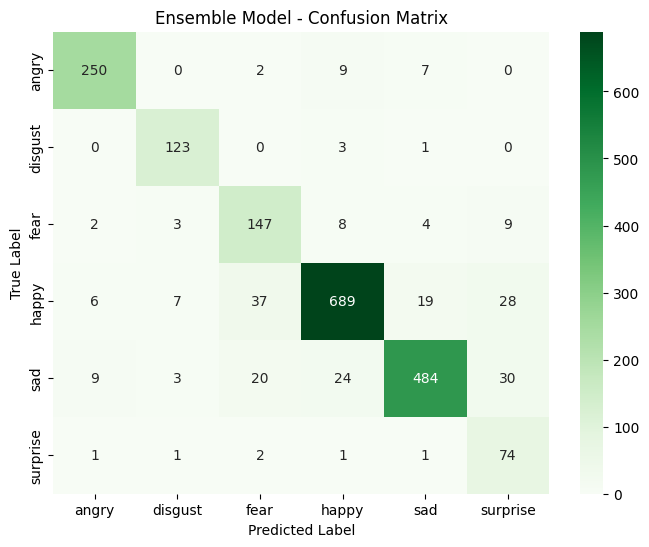

In [ ]:
# =========================
#  Evaluate Ensemble Model
# =========================
print("\n--- ENSEMBLE TEST SET RESULTS ---")
acc = accuracy_score(y_true_test, ensemble_preds)
precision, recall, f1, _ = precision_recall_fscore_support(y_true_test, ensemble_preds, average='weighted', zero_division=0)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_true_test, ensemble_preds, target_names=label_encoder.classes_))

# Save predictions
results_df = pd.DataFrame({'True_Label': y_true_test, 'Ensemble_Pred': ensemble_preds})
results_df.to_csv('ensemble_test_predictions.csv', index=False)
print("Saved test predictions to 'ensemble_test_predictions.csv'")

cm = confusion_matrix(y_true_test, ensemble_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Ensemble Model - Confusion Matrix")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


In [ ]:
# =========================
# Run Raw Text Prediction!
# =========================
def predict_emotion(text):
    bert_model.eval()
    lstm_model.eval()

    print(f"\n{'='*40}\nPREDICTING EMOTION FOR: '{text}'")
    clean_text = preprocess_text(text)

    with torch.no_grad():
        # 1. DistilBERT pipeline
        bert_enc = bert_tokenizer([clean_text], truncation=True, padding='max_length', max_length=MAX_LENGTH_BERT, return_tensors='pt')
        bert_logits = bert_model(input_ids=bert_enc['input_ids'].to(device), attention_mask=bert_enc['attention_mask'].to(device)).logits
        bert_probs = torch.softmax(bert_logits, dim=1).cpu().numpy()[0]

        # 2. BiLSTM pipeline
        seq = lstm_tokenizer.transform([clean_text])
        padded = pad_sequences_pure(seq, maxlen=MAX_LENGTH_LSTM)
        lstm_in = torch.tensor(padded, dtype=torch.long).to(device)
        lstm_logits = lstm_model(lstm_in)
        lstm_probs = torch.softmax(lstm_logits, dim=1).cpu().numpy()[0]

    # 3. Soft Vote Average
    ensemble_prob_dist = (bert_probs + lstm_probs) / 2.0
    pred_class_id = np.argmax(ensemble_prob_dist)
    confidence = ensemble_prob_dist[pred_class_id]

    predicted_label = label_encoder.inverse_transform([pred_class_id])[0]

    print(f"Ensemble Confidence: {confidence:.2%}")
    print(f"FINAL PRED: {predicted_label.upper()}")
    print('='*40)

# Test scenarios
predict_emotion("I am very happy today 😊")
predict_emotion("This is completely unacceptable and makes me so angry 😡")



PREDICTING EMOTION FOR: 'I am very happy today 😊'
Ensemble Confidence: 62.54%
FINAL PRED: HAPPY

PREDICTING EMOTION FOR: 'This is completely unacceptable and makes me so angry 😡'
Ensemble Confidence: 68.67%
FINAL PRED: ANGRY
